In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("yasserh/titanic-dataset")

print("Path to dataset files:", path)

100%|██████████████████████████████████████| 22.0k/22.0k [00:00<00:00, 12.3MB/s]

Extracting files...
Path to dataset files: /Users/nishantsoni/.cache/kagglehub/datasets/yasserh/titanic-dataset/versions/1


In [1]:
import glob, os
cache_dir = os.path.expanduser("~/.cache/kagglehub/datasets/yasserh/titanic-dataset/versions/1")
csv = glob.glob(os.path.join(cache_dir, "*.csv"))[0]
print("Found:", csv)

Found: /Users/nishantsoni/.cache/kagglehub/datasets/yasserh/titanic-dataset/versions/1/Titanic-Dataset.csv


In [2]:
import shutil
shutil.copy(csv, "Titanic-Dataset.csv")
print("Copied to:", os.path.abspath("Titanic-Dataset.csv"))

Copied to: /Users/nishantsoni/Desktop/personal/ML project/hands on projects by me/supervised learning/classification/project_2_titanic/Titanic-Dataset.csv


In [1]:
import pandas as pd
df = pd.read_csv("Titanic-Dataset.csv")
df.shape

(891, 12)

In [2]:
# import shutil
# shutil.rmtree(os.path.expanduser("~/.cache/kagglehub/datasets/yasserh/titanic-dataset"))
# print("Cache deleted.")

In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [5]:
df = pd.read_csv("Titanic-Dataset.csv")
df.shape

(891, 12)

In [6]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [8]:
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [9]:
df["Survived"].value_counts(normalize=True).round(3)

## About 62% died / 38% survived — moderately imbalanced, so we'll watch F1 alongside accuracy later.

Survived
0    0.616
1    0.384
Name: proportion, dtype: float64

In [10]:
df["Title"] = df["Name"].str.extract(r" ([A-Za-z]+)\.", expand=False)
df["Title"].value_counts()

Title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Mlle          2
Major         2
Col           2
Countess      1
Capt          1
Ms            1
Sir           1
Lady          1
Mme           1
Don           1
Jonkheer      1
Name: count, dtype: int64

In [14]:
df["Title"] = df["Title"].replace(["Mlle", "Ms"], "Miss")   # French/alt -> Miss
df["Title"] = df["Title"].replace("Mme", "Mrs")             # French -> Mrs
main_titles = ["Mr", "Mrs", "Miss", "Master"]
df["Title"] = df["Title"].where(df["Title"].isin(main_titles), "Rare")
df["Title"].value_counts()

# .where(cond, "Rare") keeps the value where the condition is true, otherwise replaces it with "Rare". 
# Now Title is a tidy 5-category column ready for one-hot encoding.

Title
Mr        517
Miss      185
Mrs       126
Master     40
Rare       23
Name: count, dtype: int64

In [17]:
df[df['Title'] == "Rare"]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
30,31,0,1,"Uruchurtu, Don. Manuel E",male,40.0,0,0,PC 17601,27.7208,NaN,C,Rare
149,150,0,2,"Byles, Rev. Thomas Roussel Davids",male,42.0,0,0,244310,13.0000,NaN,S,Rare
150,151,0,2,"Bateman, Rev. Robert James",male,51.0,0,0,S.O.P. 1166,12.5250,NaN,S,Rare
245,246,0,1,"Minahan, Dr. William Edward",male,44.0,2,0,19928,90.0000,C78,Q,Rare
249,250,0,2,"Carter, Rev. Ernest Courtenay",male,54.0,1,0,244252,26.0000,NaN,S,Rare
317,318,0,2,"Moraweck, Dr. Ernest",male,54.0,0,0,29011,14.0000,NaN,S,Rare
398,399,0,2,"Pain, Dr. Alfred",male,23.0,0,0,244278,10.5000,NaN,S,Rare
449,450,1,1,"Peuchen, Major. Arthur Godfrey",male,52.0,0,0,113786,30.5000,C104,S,Rare
536,537,0,1,"Butt, Major. Archibald Willingham",male,45.0,0,0,113050,26.5500,B38,S,Rare
556,557,1,1,"Duff Gordon, Lady. (Lucille Christiana Sutherl...",female,48.0,1,0,11755,39.6000,A16,C,Rare


In [15]:
df.groupby("Title")["Survived"].mean().sort_values().round(3)

Title
Mr        0.157
Rare      0.348
Master    0.575
Miss      0.703
Mrs       0.794
Name: Survived, dtype: float64

In [18]:
## Chunk 10 — drop the columns we don't need
df = df.drop(columns=["Name", "Ticket", "Cabin", "PassengerId"])
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title
0,0,3,male,22.0,1,0,7.2500,S,Mr
1,1,1,female,38.0,1,0,71.2833,C,Mrs
2,1,3,female,26.0,0,0,7.9250,S,Miss
3,1,1,female,35.0,1,0,53.1000,S,Mrs
4,0,3,male,35.0,0,0,8.0500,S,Mr


In [39]:
## Chunk 11 — split into features (X) and target (y)
X = df.drop(columns=["Survived"])
y = df["Survived"]
X.columns.tolist()

['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'Title']

In [40]:
##Chunk 12 — declare which columns are numeric vs categorical
numeric_features     = ["Age", "Fare", "SibSp", "Parch", "Pclass"]
categorical_features = ["Sex", "Embarked", "Title"]

In [ ]:
## Chunk 13 — train/test split (must come BEFORE imputing Age)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

X_train = X_train.copy()      # avoids pandas SettingWithCopy warnings on next step
X_test  = X_test.copy()
X_train.shape, X_test.shape

In [54]:
df.groupby("Title")["Age"].median()

Title
Master     3.5
Miss      21.0
Mr        30.0
Mrs       35.0
Rare      48.5
Name: Age, dtype: float64

In [55]:
title_medians = X_train.groupby("Title")["Age"].median()
print(title_medians)

Title
Master     3.0
Miss      22.0
Mr        30.0
Mrs       35.0
Rare      49.0
Name: Age, dtype: float64


In [56]:
## Chunk 14 — impute Age by Title median (train-aware)
title_medians = X_train.groupby("Title")["Age"].median()
print(title_medians)

X_train["Age"] = X_train["Age"].fillna(X_train["Title"].map(title_medians))
X_test["Age"]  = X_test["Age"].fillna(X_test["Title"].map(title_medians))

# confirm no missing Age left
X_train["Age"].isna().sum(), X_test["Age"].isna().sum()

Title
Master     3.0
Miss      22.0
Mr        30.0
Mrs       35.0
Rare      49.0
Name: Age, dtype: float64


(0, 0)

In [57]:
## Chunk 15 — preprocessing WITHOUT a pipeline
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# NUMERIC: impute (safety net) + scale
num_imputer = SimpleImputer(strategy="median")
Xtr_num = num_imputer.fit_transform(X_train[numeric_features])
Xte_num = num_imputer.transform(X_test[numeric_features])

scaler = StandardScaler()
Xtr_num = scaler.fit_transform(Xtr_num)
Xte_num = scaler.transform(Xte_num)

# CATEGORICAL: impute most_frequent + one-hot
cat_imputer = SimpleImputer(strategy="most_frequent")
Xtr_cat = cat_imputer.fit_transform(X_train[categorical_features])
Xte_cat = cat_imputer.transform(X_test[categorical_features])

ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
Xtr_cat = ohe.fit_transform(Xtr_cat)
Xte_cat = ohe.transform(Xte_cat)

# STITCH numeric + categorical
X_train_manual = np.hstack([Xtr_num, Xtr_cat])
X_test_manual  = np.hstack([Xte_num, Xte_cat])
X_train_manual.shape, X_test_manual.shape

((712, 15), (179, 15))

In [58]:
## Chunk 16 — preprocessing WITH a pipeline
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
])
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot",  OneHotEncoder(handle_unknown="ignore")),
])
preprocessor = ColumnTransformer([
    ("num", numeric_transformer,     numeric_features),
    ("cat", categorical_transformer, categorical_features),
])

X_train_pipe = preprocessor.fit_transform(X_train)
X_test_pipe  = preprocessor.transform(X_test)
X_train_pipe.shape, X_test_pipe.shape

((712, 15), (179, 15))

In [59]:
## Chunk 17 — prove both give the identical result
a = X_train_pipe.toarray() if hasattr(X_train_pipe, "toarray") else X_train_pipe
np.allclose(a, X_train_manual)

True

## NOTE - 
Your proposed order (prepare all the data → then split) feels natural — "clean it, then divide it" — but for the steps that learn from the data, it causes data leakage, and your scores become optimistically wrong.
Here's the key idea: several preprocessing steps don't just transform data, they learn a parameter from it:

Imputation learns the median/mean/most-frequent from the data.
Scaling (StandardScaler) learns the mean and standard deviation from the data.
OneHotEncoder learns the set of categories from the data.

If you fit these on the full dataset before splitting, then the test set's values leak into those learned parameters — and then get baked into how the training data is processed. Your test set is no longer truly "unseen." The result: your test score looks better than reality, and it won't hold up on genuinely new data.
Concrete example. Say you scale using the mean of the whole dataset (train + test). That mean includes test rows. When you scale the training data, you've quietly used information about the test set. At evaluation time your score is inflated, because the preprocessing already "peeked" at the test distribution. On real new data — which you obviously couldn't include in that mean — you'd do worse than your test score promised. That gap is leakage.
So the correct order (what we did) is:

Split into train/test first.
Fit preprocessing on train only (learn median, mean/std, categories from train).
Apply that fitted preprocessing to both train and test.
Test statistics never influence anything → honest evaluation.

This is exactly why the pipeline fits the preprocessor on X_train and merely transforms X_test with the train-derived parameters. -->

In [60]:
# Chunk 18 — one full pipeline (preprocessor + model), to see it work
from sklearn.linear_model import LogisticRegression

clf = Pipeline([
    ("prep",  preprocessor),                       # all your preprocessing
    ("model", LogisticRegression(max_iter=1000)),  # the model
])
clf.fit(X_train, y_train)
print("Test accuracy:", round(clf.score(X_test, y_test), 4))

Test accuracy: 0.8324


In [61]:
# Chunk 19 — import the model lineup

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

In [62]:
# Chunk 20 — models dictionary
models = {
    "LogisticRegression": LogisticRegression(max_iter=1000),
    "KNN":                KNeighborsClassifier(),
    "SVM":                SVC(),
    "DecisionTree":       DecisionTreeClassifier(random_state=42),
    "RandomForest":       RandomForestClassifier(random_state=42),
    "GradientBoosting":   GradientBoostingClassifier(random_state=42),
    "XGBoost":            XGBClassifier(random_state=42),
    "CatBoost":           CatBoostClassifier(random_state=42, verbose=0),
    "NaiveBayes":         GaussianNB(),
}

In [63]:
# Chunk 21 — cross-validate every model (inside the pipeline)
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = {}
for name, model in models.items():
    pipe = Pipeline([("prep", preprocessor), ("model", model)])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="accuracy")
    results[name] = scores.mean()
    print(f"{name:20s}: {scores.mean():.4f}  (+/- {scores.std():.4f})")

LogisticRegression  : 0.8216  (+/- 0.0212)
KNN                 : 0.8090  (+/- 0.0133)
SVM                 : 0.8230  (+/- 0.0174)
DecisionTree        : 0.7655  (+/- 0.0119)
RandomForest        : 0.7964  (+/- 0.0129)
GradientBoosting    : 0.8244  (+/- 0.0315)
XGBoost             : 0.8160  (+/- 0.0112)
CatBoost            : 0.8230  (+/- 0.0250)
NaiveBayes          : 0.8020  (+/- 0.0236)


In [53]:
X_train[X_train["Title"] == "Master"]["Age"].describe()

count    31.000000
mean      4.118387
std       3.371721
min       0.420000
25%       1.000000
50%       3.000000
75%       6.500000
max      12.000000
Name: Age, dtype: float64

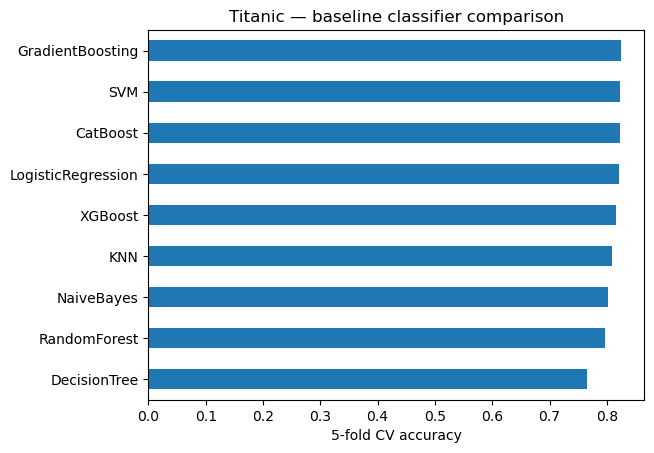

In [64]:
#  Chunk 22 — sorted results
results_df = pd.DataFrame(results, index=["cv_accuracy"]).T
results_df.sort_values("cv_accuracy", ascending=False)

# Chunk 23 — plot the ranking
results_df.sort_values("cv_accuracy").plot(kind="barh", legend=False)
plt.xlabel("5-fold CV accuracy")
plt.title("Titanic — baseline classifier comparison");

HERE, WE GET THE GradientBoosting, SVM HIGHER, ON THIS WE CANT SELECT THE BEST MODEL, WE SHOULD CHECK THE SCORE ALSO, BECAUSE SCORE DEDICE THE BEST MODEL, HERE DATA IS IMBALANCE, ~62% died / 38% survived, SO WE CAN GET WRONG PRIDICTION OR RESULT COULD LEAN TOWARD THE MAJORITY 

Titanic is imbalanced (~62% died / 38% survived), so accuracy can flatter a model that just leans toward the majority. F1 (which balances precision and recall on the "survived" class) is the more honest single number. Let me get F1 and the other metrics for all models in one pass.

In [65]:
# Chunk 24 — cross-validate all models on multiple metrics at once
from sklearn.model_selection import cross_validate

scoring = ["accuracy", "precision", "recall", "f1", "roc_auc"]

multi_results = {}
for name, model in models.items():
    pipe = Pipeline([("prep", preprocessor), ("model", model)])
    cv_out = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring)
    multi_results[name] = {m: cv_out[f"test_{m}"].mean() for m in scoring}
    print(f"{name:20s} F1={multi_results[name]['f1']:.4f}  Acc={multi_results[name]['accuracy']:.4f}")

LogisticRegression   F1=0.7623  Acc=0.8216
KNN                  F1=0.7402  Acc=0.8090
SVM                  F1=0.7503  Acc=0.8230
DecisionTree         F1=0.6913  Acc=0.7655
RandomForest         F1=0.7286  Acc=0.7964
GradientBoosting     F1=0.7586  Acc=0.8244
XGBoost              F1=0.7523  Acc=0.8160
CatBoost             F1=0.7494  Acc=0.8230
NaiveBayes           F1=0.7467  Acc=0.8020


In [66]:
## Chunk 25 — full comparison table, sorted by F1
metrics_df = pd.DataFrame(multi_results).T
metrics_df.sort_values("f1", ascending=False).round(4)

,accuracy,precision,recall,f1,roc_auc
LogisticRegression,0.8216,0.7845,0.7436,0.7623,0.8692
GradientBoosting,0.8244,0.8066,0.7177,0.7586,0.8864
XGBoost,0.8160,0.7784,0.7288,0.7523,0.8809
SVM,0.8230,0.8207,0.6958,0.7503,0.8645
CatBoost,0.8230,0.8224,0.6921,0.7494,0.8807
NaiveBayes,0.8020,0.7339,0.7618,0.7467,0.8423
KNN,0.8090,0.7771,0.7106,0.7402,0.8554
RandomForest,0.7964,0.7448,0.7142,0.7286,0.8668
DecisionTree,0.7655,0.7003,0.6851,0.6913,0.7482


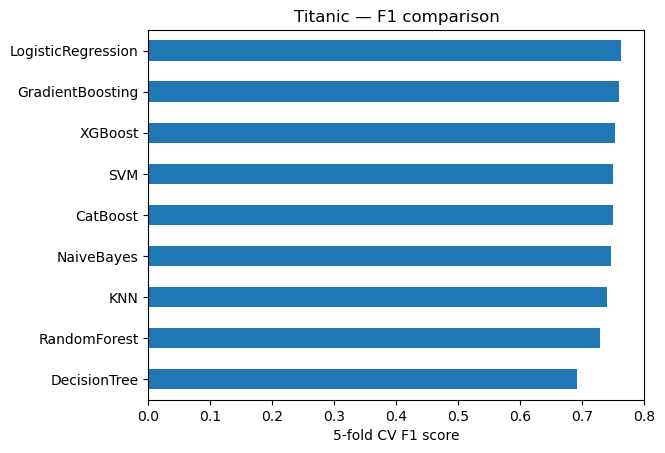

In [67]:
## Chunk 26 — plot the F1 ranking
metrics_df.sort_values("f1")["f1"].plot(kind="barh")
plt.xlabel("5-fold CV F1 score")
plt.title("Titanic — F1 comparison");

In [ ]:
## Session 4 — Tune the Top 3 model - LogisticRegression, GradientBoosting and XGBOOST

In [94]:
# Chunk 27 — tune LogisticRegression (GridSearchCV)
from sklearn.model_selection import GridSearchCV

logreg_pipe = Pipeline([("prep", preprocessor),
                        ("model", LogisticRegression(max_iter=100))])

logreg_grid = {
    "model__C":       [0.01, 0.1, 1, 10, 100],
    "model__penalty": ["l1", "l2"],
    "model__solver":  ["liblinear"],
}
gs_lr = GridSearchCV(logreg_pipe, logreg_grid, cv=cv, scoring="f1", n_jobs=-1)
# gs_lr = GridSearchCV(logreg_pipe, logreg_grid, cv=cv, scoring="accuracy", n_jobs=-1)
gs_lr.fit(X_train, y_train)
print("LogReg  best F1:", round(gs_lr.best_score_, 4), "|", gs_lr.best_params_)

LogReg  best F1: 0.7712 | {'model__C': 100, 'model__penalty': 'l1', 'model__solver': 'liblinear'}


In [86]:
# Chunk 28 — tune GradientBoosting (RandomizedSearchCV)
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

gb_pipe = Pipeline([("prep", preprocessor),
                    ("model", GradientBoostingClassifier(random_state=42))])

gb_dist = {
    "model__n_estimators":     randint(10, 500),
    "model__learning_rate":    uniform(0.01, 0.3),
    "model__max_depth":        [2, 3, 4, 5],
    "model__min_samples_leaf": randint(1, 20),
    "model__subsample":        uniform(0.7, 0.3),   # samples 0.7–1.0
}
rs_gb = RandomizedSearchCV(gb_pipe, gb_dist, n_iter=25, cv=cv,
                           scoring="f1", random_state=42, n_jobs=-1)
rs_gb.fit(X_train, y_train)
print("GB      best F1:", round(rs_gb.best_score_, 4), "|", rs_gb.best_params_)

GB      best F1: 0.7788 | {'model__learning_rate': 0.150028867974394, 'model__max_depth': 2, 'model__min_samples_leaf': 19, 'model__n_estimators': 144, 'model__subsample': 0.7511572371061874}


In [89]:
# Chunk 29 — tune XGBoost (RandomizedSearchCV)
xgb_pipe = Pipeline([("prep", preprocessor),
                     ("model", XGBClassifier(random_state=42))])

xgb_dist = {
    "model__n_estimators":     randint(100, 500),
    "model__learning_rate":    uniform(0.01, 0.3),
    "model__max_depth":        [2, 3, 4, 5, 6],
    "model__subsample":        uniform(0.7, 0.3),
    "model__colsample_bytree": uniform(0.7, 0.3),
}
rs_xgb = RandomizedSearchCV(xgb_pipe, xgb_dist, n_iter=25, cv=cv,
                            scoring="f1", random_state=42, n_jobs=-1)
rs_xgb.fit(X_train, y_train)
print("XGB     best F1:", round(rs_xgb.best_score_, 4), "|", rs_xgb.best_params_)

XGB     best F1: 0.7702 | {'model__colsample_bytree': 0.8199582915145766, 'model__learning_rate': 0.023999698964084628, 'model__max_depth': 5, 'model__n_estimators': 370, 'model__subsample': 0.8368209952651107}


In [95]:
# Chunk 30 — compare all three tuned models: F1 and accuracy, CV and test
from sklearn.metrics import f1_score, accuracy_score
from sklearn.model_selection import cross_val_score

tuned = {"LogReg": gs_lr, "GradientBoosting": rs_gb, "XGBoost": rs_xgb}

rows = {}
for name, m in tuned.items():
    best   = m.best_estimator_
    cv_f1  = m.best_score_                                                    # CV F1 (the tuned metric)
    cv_acc = cross_val_score(best, X_train, y_train, cv=cv, scoring="accuracy").mean()
    pred   = m.predict(X_test)                                               # one peek at test
    rows[name] = {
        "CV_F1":    cv_f1,
        "CV_Acc":   cv_acc,
        "Test_F1":  f1_score(y_test, pred),
        "Test_Acc": accuracy_score(y_test, pred),
    }

compare_df = pd.DataFrame(rows).T.round(4)
compare_df.sort_values("CV_F1", ascending=False)

,CV_F1,CV_Acc,Test_F1,Test_Acc
GradientBoosting,0.7788,0.8385,0.7656,0.8324
LogReg,0.7712,0.8287,0.7820,0.8380
XGBoost,0.7702,0.8314,0.7727,0.8324
